# Project Context: Review Summarization Service

This project focuses on developing a service designed to help businesses quickly obtain useful summaries of their customer reviews collected from various websites. Such a service enables business clients to answer key questions, such as:

- **What are the most important factors driving negative reviews?**
- **Did a recent policy change improve our customer feedback?**

## Imports 

In [5]:
import nltk # imports the natural language toolkit
nltk.download('punkt')
nltk.download('stopwords')
import pandas as pd
import numpy as np
import string
import plotly
import matplotlib.pyplot as plt
from nltk.stem import PorterStemmer


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\newUs\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\newUs\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Load data from data-set

In [6]:
# LOADING THE DATASET AND SEEING THE DETAILS
# If your computer can handle the entire dataset remove the nrows=5000
data = pd.read_csv(r'data\sdata.csv', nrows=5000)
data.head()

,review_id,user_id,business_id,stars,date,text,useful,funny,cool
0,vkVSCC7xljjrAI4UGfnKEQ,bv2nCi5Qv5vroFiqKGopiw,AEx2SYEUJmTxVVB18LlCwA,5,2016-05-28,Super simple place but amazing nonetheless. It...,0,0,0
1,n6QzIUObkYshz4dz2QRJTw,bv2nCi5Qv5vroFiqKGopiw,VR6GpWIda3SfvPC-lg9H3w,5,2016-05-28,Small unassuming place that changes their menu...,0,0,0
2,MV3CcKScW05u5LVfF6ok0g,bv2nCi5Qv5vroFiqKGopiw,CKC0-MOWMqoeWf6s-szl8g,5,2016-05-28,Lester's is located in a beautiful neighborhoo...,0,0,0
3,IXvOzsEMYtiJI0CARmj77Q,bv2nCi5Qv5vroFiqKGopiw,ACFtxLv8pGrrxMm6EgjreA,4,2016-05-28,Love coming here. Yes the place always needs t...,0,0,0
4,L_9BTb55X0GDtThi6GlZ6w,bv2nCi5Qv5vroFiqKGopiw,s2I_Ni76bjJNK9yG60iD-Q,4,2016-05-28,Had their chocolate almond croissant and it wa...,0,0,0


In [7]:
AllReviews = data['text']
AllReviews.head()

0    Super simple place but amazing nonetheless. It...
1    Small unassuming place that changes their menu...
2    Lester's is located in a beautiful neighborhoo...
3    Love coming here. Yes the place always needs t...
4    Had their chocolate almond croissant and it wa...
Name: text, dtype: object

# 1. Question about dataset
What are the most frequent words or topics mentioned in customer reviews for this business?

In [12]:
from collections import Counter


# Combine all reviews text
all_reviews_text = " ".join(data['text'].astype(str).tolist())

# Tokenize the text into words
words = nltk.word_tokenize(all_reviews_text.lower())

# Remove punctuation and stopwords
words = [w for w in words if w.isalpha()]  # Keep only alphabetic words

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
filtered_words = [w for w in words if w not in stop_words]

# Count word frequencies
word_freq = Counter(filtered_words)
most_common_words = word_freq.most_common(10)

print("Most common words in customer reviews:")
for word, freq in most_common_words:
    print(f"{word}: {freq}")

Most common words in customer reviews:
place: 2972
good: 2870
food: 2689
one: 2310
like: 2250
great: 2083
would: 1998
time: 1967
get: 1871
really: 1842


In [ ]:
# Print text of first Yelp review
AllReviews[0]

# sentence tokenization
sentences = nltk.sent_tokenize(AllReviews[0])
for sentence in sentences:
    print("\n" + sentence)
    print()



Super simple place but amazing nonetheless.


It's been around since the 30's and they still serve the same thing they started with: a bologna and salami sandwich with mustard.


Staff was very helpful and friendly.



# 2. Question about dataset

- Analysis of the sizes of reviews

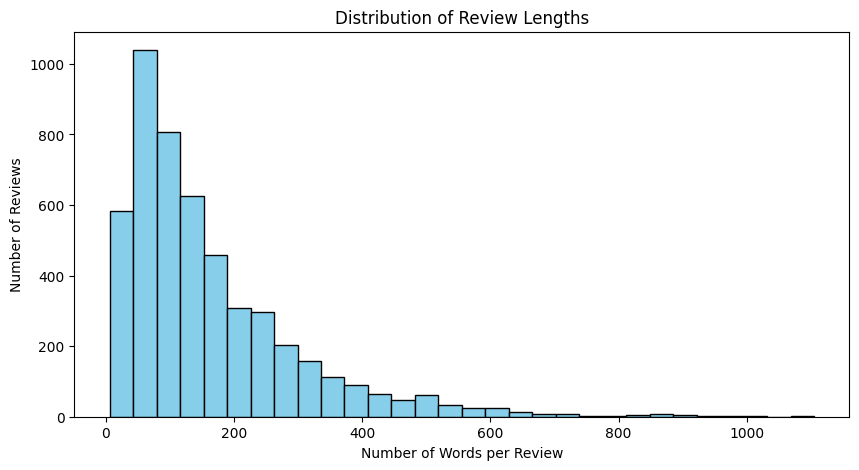

Shortest review (6 words):
Bon  Muffin !!! Succulent

Longest review (1105 words):
First things first - I am a road cyclist and a spin class junkie (though I prefer the term "aficionado"). Last week, I posted the following to my Facebook status after yet another predictably boring YMCA spin class, "If 90+% of your class has us out of the saddle or doing ridiculous 'jumps', it's not a cycle class. It's an elliptical class. It is also a waste of my time."

After reading that Facebook status, a friend of mine sent me an invitation to the "Open House Week" at Flywheel Ballantyne. I had never heard of Flywheel before, but my friend said they were offering free classes all week and suggested we try them. I wrote her back saying, "Given what they charge, I'm interested in seeing how - if at all - this is different from a general spin class." Frankly, having spent hundreds of hours in YMCA spin classes over the past 3 years, I was not expecting much.

I told her as I gripped the handrail down 

In [16]:



# Calculate review lengths (number of words per review)
review_lengths = data['text'].apply(lambda x: len(nltk.word_tokenize(x)))

# Find the shortest review
min_length = review_lengths.min()
shortest_review = data['text'][review_lengths.idxmin()]

# Find the longest review
max_length = review_lengths.max()
longest_review = data['text'][review_lengths.idxmax()]

# Plot histogram of review lengths
plt.figure(figsize=(10,5))
plt.hist(review_lengths, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Words per Review')
plt.ylabel('Number of Reviews')
plt.show()

# Print results
print("Shortest review ({} words):\n{}".format(min_length, shortest_review))
print("\nLongest review ({} words):\n{}".format(max_length, longest_review))


# 3. Question about dataset

Word cloud

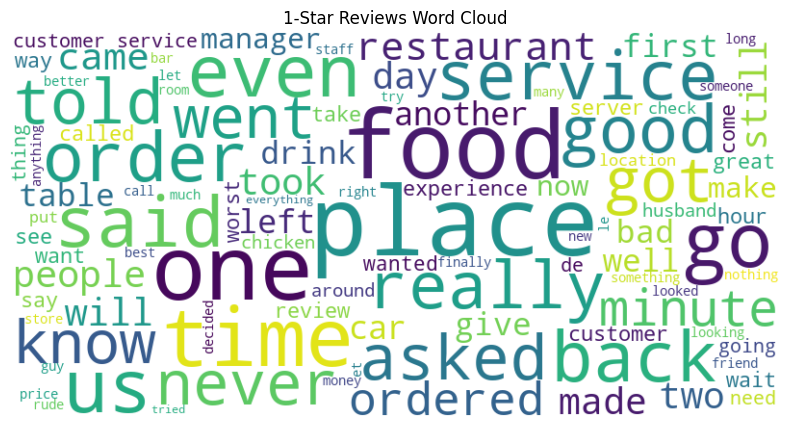

In [ ]:
from wordcloud import WordCloud


def word_cloud_rating(data, star_value):
    filtered_reviews = data[data['stars'] == star_value]
    text = ' '.join(filtered_reviews['text'])
    wordcloud = WordCloud(max_font_size=100, max_words=100, background_color="white", width=800, height=400).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"{star_value}-Star Reviews Word Cloud")
    plt.show()

word_cloud_rating(data, 1)


# 4. Question about dataset

The word "good" seems to appear quite frequently in the negative reviews. Investigate why that is and come up with a reasonable explanation. 

# Answer:

- The word "good" seems to appear quite frequently in the negative reviews. Investigate why that is and come up with a reasonable explanation.

# 5. Question about dataset

Find all the high-frequency (top 1%) and low-frequency (bottom 1%) words in the reviews overall.

In [11]:

import re
import unicodedata
from collections import Counter
from nltk.corpus import stopwords

# Ensure you have NLTK stopwords downloaded
# import nltk
# nltk.download('stopwords')

# Load your data
# data = pd.read_csv('sdata.csv')

def preprocess_text(text):
    # Remove accents
    text = ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )
    # Lowercase
    text = text.lower()
    # Remove numbers and non-alphabetical characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize and remove stop words
    stop_words = set(stopwords.words('english'))
    words = [w for w in text.split() if w not in stop_words]
    return words

# Combine and preprocess all reviews
all_reviews = ' '.join(data['text'])
words = preprocess_text(all_reviews)

# Count frequencies
word_counts = Counter(words)
total_unique_words = len(word_counts)
top_1pct = int(np.ceil(total_unique_words * 0.01))
bottom_1pct = int(np.ceil(total_unique_words * 0.01))

# Top 1% most frequent words
high_freq_words = word_counts.most_common(top_1pct)
# Bottom 1% least frequent words
low_freq_words = word_counts.most_common()[:-bottom_1pct-1:-1]

print("Top 1% most frequent words (after preprocessing):", high_freq_words)
print("Bottom 1% least frequent words (after preprocessing):", low_freq_words)


Top 1% most frequent words (after preprocessing): [('place', 2959), ('good', 2855), ('food', 2675), ('one', 2291), ('like', 2243), ('great', 2076), ('time', 1959), ('get', 1872), ('really', 1836), ('would', 1767), ('back', 1620), ('also', 1618), ('service', 1601), ('go', 1592), ('well', 1291), ('im', 1255), ('dont', 1236), ('nice', 1195), ('little', 1167), ('ordered', 1144), ('ive', 1085), ('even', 1076), ('us', 1023), ('try', 980), ('always', 972), ('came', 961), ('menu', 935), ('pretty', 935), ('love', 932), ('order', 922), ('got', 918), ('much', 894), ('people', 886), ('could', 882), ('didnt', 882), ('first', 863), ('de', 863), ('two', 857), ('never', 844), ('staff', 835), ('restaurant', 833), ('chicken', 816), ('come', 811), ('bar', 793), ('best', 788), ('make', 783), ('went', 780), ('definitely', 771), ('friendly', 764), ('made', 734), ('know', 734), ('delicious', 732), ('sure', 704), ('around', 703), ('think', 700), ('though', 678), ('right', 670), ('way', 657), ('going', 655), (

# 6. Question about dataset
Write a function called top_k_ngrams(word_tokens, n, k) for printing out the top k n-grams. 

In [12]:
from collections import Counter
from nltk.util import ngrams

def top_k_ngrams(word_tokens, n, k):
    n_grams = ngrams(word_tokens, n)
    ngram_freq = Counter(n_grams)
    top_k = ngram_freq.most_common(k)
    for ngram, freq in top_k:
        print(f"{' '.join(ngram)}: {freq}")

# Example for the first 1000 reviews:
first_1000 = ' '.join(data['text'][:1000]).lower()
words = nltk.word_tokenize(first_1000)
print("Top 10 1-grams:")
top_k_ngrams(words, 1, 10)

print("\nTop 10 2-grams:")
top_k_ngrams(words, 2, 10)

print("\nTop 10 3-grams:")
top_k_ngrams(words, 3, 10)


Top 10 1-grams:
.: 10808
the: 8623
,: 6198
i: 5953
and: 5587
a: 4846
to: 4403
it: 3333
was: 3069
of: 2876

Top 10 2-grams:
. i: 1946
. the: 1507
, but: 867
. it: 725
it 's: 694
it was: 643
of the: 603
, and: 603
in the: 536
i was: 535

Top 10 3-grams:
. it 's: 241
. it was: 194
, but i: 168
. i 've: 163
. i was: 143
i do n't: 131
. i 'm: 120
it 's a: 117
. the food: 105
, but it: 103


# 6 question about dataset

Exercise 5 (with preprocessing)
Find all the high-frequency (top 1%) and low-frequency (bottom 1%) words in the reviews overall

In [13]:
from nltk.corpus import stopwords

first_review = data['text'][0]
words = nltk.word_tokenize(first_review.lower())
stop_words = set(stopwords.words('english'))

filtered_words = [w for w in words if w.isalpha() and w not in stop_words]
found_stopwords = [w for w in words if w in stop_words]

print("Filtered review (no stopwords):")
print(filtered_words)

print("\nStopwords found in review:")
print(found_stopwords)


Filtered review (no stopwords):
['super', 'simple', 'place', 'amazing', 'nonetheless', 'around', 'since', 'still', 'serve', 'thing', 'started', 'bologna', 'salami', 'sandwich', 'mustard', 'staff', 'helpful', 'friendly']

Stopwords found in review:
['but', 'it', 'been', 'the', 'and', 'they', 'the', 'same', 'they', 'with', 'a', 'and', 'with', 'was', 'very', 'and']


# 7.1 Question about dataset
Filter out all of the stop words in the first review of the Yelp review data and print out your answer.


In [ ]:
from nltk.corpus import stopwords

first_review = data['text'][0]
words = nltk.word_tokenize(first_review.lower())
stop_words = set(stopwords.words('english'))

filtered_words = [w for w in words if w.isalpha() and w not in stop_words]
found_stopwords = [w for w in words if w in stop_words]

print("Filtered review (no stopwords):")
print(filtered_words)

print("\nStopwords found in review:")
print(found_stopwords)


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

good_reviews = data[data['stars'] > 3]['text']
bad_reviews = data[data['stars'] <= 3]['text']

def plot_top_words(corpus, n=20, title="Top Words"):
    vec = CountVectorizer(stop_words='english', max_features=n)
    X = vec.fit_transform(corpus)
    words = vec.get_feature_names_out()
    freqs = X.sum(axis=0).A1
    sorted_idx = freqs.argsort()[::-1]
    plt.figure(figsize=(10,4))
    plt.bar([words[i] for i in sorted_idx], [freqs[i] for i in sorted_idx])
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

plot_top_words(good_reviews, 20, "Top 20 Words in Good Reviews")
plot_top_words(bad_reviews, 20, "Top 20 Words in Bad Reviews")
